In [35]:
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm
import normflows as nf
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [18]:
from pathlib import Path

num_batches = 200

data_dir = Path('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_samples_1e6/')

coord_list = []
current_list = []
voltage_list = []
input_idx = 0 # input_idx AFTER sorting out the output electrode
output_idx = 0

for i in range(num_batches):

    fp = data_dir / f'batch_{i}.npz'
    try:
        batch = np.load(fp)
    except FileNotFoundError:
        continue        

    voltage_list.append(batch['inputs'][..., input_idx+1])
    coord_list.append(batch['acc_xy'])    

    if batch['currents'].ndim != 1:
        current_list.append(batch['currents'][:, output_idx])
    else:
        current_list.append(batch['currents'])

# You need to change this if you changed simulation parameters
radius = 150.0
n_a = 200
R = np.sqrt(radius ** 2 * np.pi / n_a)
print(R)

coord_set = np.concatenate(coord_list) * R / radius
current_set = np.concatenate(current_list)
voltage_set = np.concatenate(voltage_list)

print('Dataset loaded')

print(coord_set.shape)
print(voltage_set.shape)
print(current_set.shape)

18.799712059732506
Dataset loaded
(200000, 200, 2)
(200000,)
(200000,)


In [19]:
from torch.utils.data import Dataset, TensorDataset, DataLoader
from torch.utils.data import random_split
from train_sm import MakeDataset

train_size = 0.8
val_size = 0.1
test_size = 0.1

r2 = np.sum(coord_set**2, axis=-1)
print(r2.max())
idx = np.argsort(r2, axis=1)
sorted_coord_set = np.take_along_axis(
    coord_set,
    idx[..., None],
    axis=1
)

X = torch.from_numpy(sorted_coord_set).float()
C = torch.from_numpy(np.concatenate([voltage_set.reshape(-1, 1), current_set.reshape(-1, 1)], axis=1)).float()

num_samples = 50000
X = X[:num_samples, ...]
C = C[:num_samples, ...]

print(current_set.max(), current_set.min())

print(X.shape)
print(C.shape)

dataset = TensorDataset(X, C)

generator_1 = torch.Generator().manual_seed(32)
train_ds, val_ds, test_ds = random_split(dataset, lengths=[train_size, val_size, test_size], generator=generator_1)

batch_size = 2048*2
num_workers = 4
pin_memory = True
persistent_workers=True
prefetch_factor = 4

train_loader = DataLoader(
    train_ds, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=num_workers, 
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    prefetch_factor=prefetch_factor
)
val_loader = DataLoader(
    val_ds, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=num_workers, 
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    prefetch_factor=prefetch_factor
)
test_loader = DataLoader(
    test_ds, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=num_workers, 
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    prefetch_factor=prefetch_factor
)

print(len(train_loader.dataset))
print(len(val_loader.dataset))
print(len(test_loader.dataset))
print('Dataloaders ready')

0.9999999596925788
1.126821151711627 -0.951992901019707
torch.Size([50000, 200, 2])
torch.Size([50000, 2])
40000
5000
5000
Dataloaders ready


In [20]:
K = 4
hidden_layers = 3   
hidden_units = 64   
num_context_dims = 2
latent_size = 400

flows = []
for i in range(K):
    flows += [
        nf.flows.CoupledRationalQuadraticSpline(
            latent_size,
            hidden_layers,
            hidden_units,
            num_context_channels=num_context_dims
        ),
        # Linear mixing between blocks
        nf.flows.LULinearPermute(latent_size),
    ]

# Diagonal Gaussian base
q0 = nf.distributions.DiagGaussian(latent_size, trainable=False)

nfm = nf.ConditionalNormalizingFlow(q0=q0, flows=flows)
nfm = nfm.to(device)

print('Coupling spline flow model created')

Coupling spline flow model created


In [24]:
num_epochs = 400

optimizer = torch.optim.Adam(nfm.parameters(), lr=2e-3)

train_losses = []
val_losses = []

with tqdm(total=num_epochs, desc="Epochs") as pbar:
    for epoch in range(1, num_epochs + 1):
    
        nfm.train()
        train_loss = 0.0
        n_train = 0
        for x, c in train_loader:

            x = x.reshape(-1, 200*2)
            x = x.to(device, non_blocking=True)       
            c = c.to(device, non_blocking=True)
    
            loss = nfm.forward_kld(x, context=c)
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
            batch_size = x.size(0)
            train_loss += loss.item() * batch_size
            n_train += batch_size

        train_loss /= n_train
        train_losses.append(train_loss)
    
        nfm.eval()
        val_loss = 0.0
        n_val = 0
    
        with torch.no_grad():
            for x_val, c_val in val_loader:
                x_val = x_val.reshape(-1, 200*2)
                x_val = x_val.to(device, non_blocking=True)
                c_val = c_val.to(device, non_blocking=True)
    
                loss_val = nfm.forward_kld(x_val, context=c_val)
                
                batch_size = x_val.size(0)
                val_loss += loss_val.item() * batch_size
                n_val += batch_size
    
        val_loss /= n_val
        val_losses.append(val_loss)
    
        pbar.set_postfix({
            "Epoch": f"{epoch:03d}",
            "train NLL": f"{train_loss:.4f}",
            "val NLL": f"{val_loss:.4f}"
        })
        pbar.update(1)

print('Training is Done')

Epochs: 100%|██████████| 400/400 [35:20<00:00,  5.30s/it, Epoch=400, train NLL=-281.9655, val NLL=-235.7092]

Training is Done


In [26]:
torch.save(
    {
        "state_dict()": nfm.state_dict(),        
        "train_losses": train_losses,
        "val_losses": val_losses
    }, 
    f=f'/gpfs/bwfor/work/ws/hd_gy283-my_data/models/spline_flow_K={K}_LS={latent_size}_HL{hidden_layers}_epochs={num_epochs}_w_context.pth'
)
print('Model saved')

Model saved


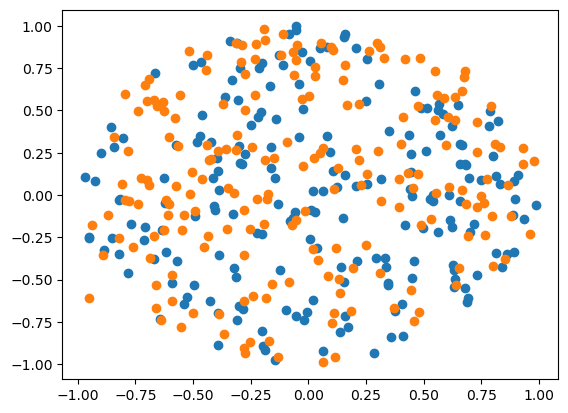

In [108]:
nfm.eval()

x_real, c_real = next(iter(test_loader))
x_real = x_real.reshape(x_real.size(0), -1).to(device)
c_real = c_real.to(device)

with torch.no_grad():
    x_samp, _ = nfm.sample(num_samples=x_real.size(0), context=c_real)

x_real = x_real.detach().cpu().numpy().reshape(-1, 200, 2)
x_samp = x_samp.detach().cpu().numpy().reshape(-1, 200, 2)

idx = 0
plt.scatter(*x_real[idx].T)
plt.scatter(*x_samp[idx].T)

In [33]:
nfm.eval()

num_samples = 100
context = torch.tensor([-1.0, 0.0]).expand(num_samples, -1)

with torch.no_grad():
    c_input = context.to(device)
    x, _ = nfm.sample(num_samples=num_samples, context=c_input)

x_samples = x.detach().cpu().numpy().reshape(-1, 2)
print(x_samples.shape)

(20000, 2)


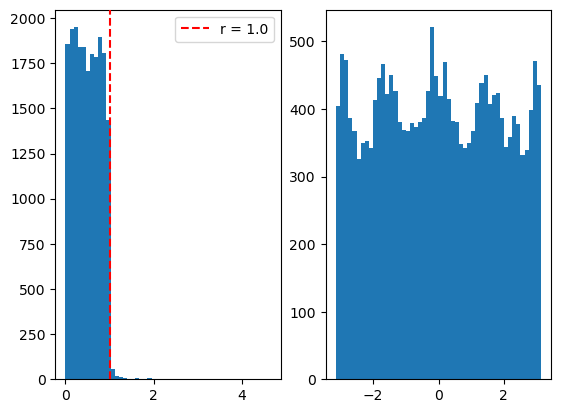

In [52]:
radii_2 = (x_samples ** 2).sum(axis=-1)
thetas = np.atan2(x_samples[..., 1], x_samples[..., 0])

fig, ax = plt.subplots(ncols=2)
bins=50
ax[0].hist(radii_2, bins=bins)
ax[0].axvline(1.0, color='r', ls='dashed', alpha=1, label='r = 1.0', zorder=5)
ax[0].legend()
ax[1].hist(thetas, bins=bins)
plt.show()

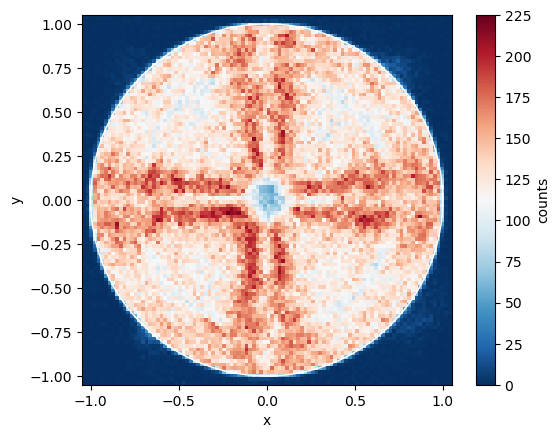

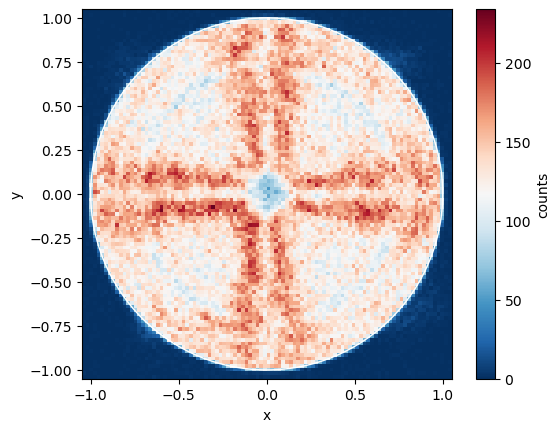

In [132]:
def sample_cfg(model, c_single, num_samples=200, device=device):

    model.eval()

    with torch.no_grad():
        c_batch = c_single.unsqueeze(0).expand(num_samples, -1).to(device)

        x, _ = model.sample(num_samples, c_batch)
    
    return x.detach().cpu().numpy().reshape(-1, 2)

def plot_2d_heatmap(points, title="Heatmap", R=1.0, bins=100):

    import matplotlib.patches as ps
        
    if isinstance(points, torch.Tensor):
        points = points.cpu().numpy()

    x = points[:, 0]
    y = points[:, 1]
    
    range_ = [[-R-pad, R+pad], [-R-pad, R+pad]]

    fig, ax = plt.subplots()
    H , xedges, yedges, im = ax.hist2d(x, y, bins=bins, range=range_, cmap='RdBu_r')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('counts')
    ax.set_aspect("equal", "box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    
    ax.add_patch(ps.Circle(xy=(0,0), radius=R, fill=None, color='w', zorder=6))

pts_0 = sample_cfg(nfm, c_single=torch.tensor([1.5, 1.1]), num_samples=5000)
pts_1 = sample_cfg(nfm, c_single=torch.tensor([1.5, -0.9]), num_samples=5000)

plot_2d_heatmap(pts_0)
plot_2d_heatmap(pts_1)

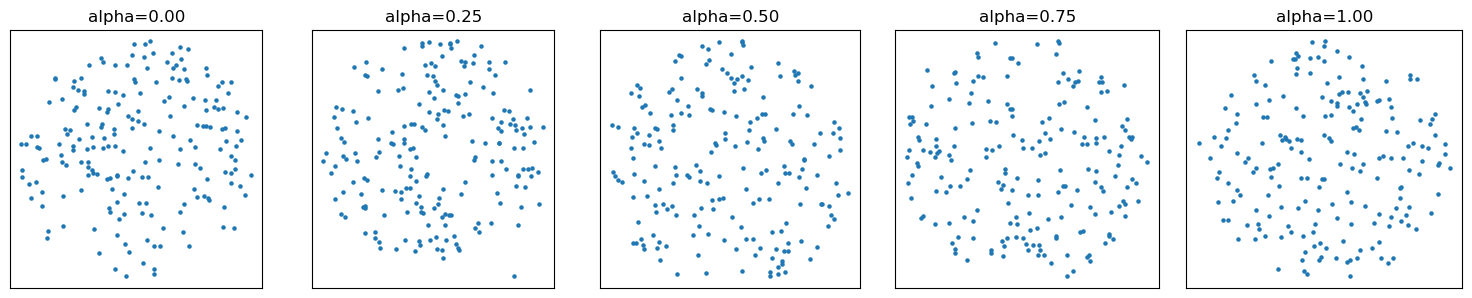

In [129]:
c_a = c_real[0:1]
c_b = c_real[1:2]

#print(c_a, c_b)

n_steps = 5
alphas = torch.linspace(0, 1, steps=n_steps).to(device)
all_samples = []
all_contexts = []

with torch.no_grad():
    for alpha in alphas:
        c_interp = alpha * c_a + (1 - alpha) * c_b
        c_batch_interp = c_interp.expand(128, -1)
        samples, _ = nfm.sample(128, context=c_batch_interp)
        all_samples.append(samples.cpu().numpy().reshape(-1, 200, 2))
        all_contexts.append(c_interp.cpu().numpy())

fig, axes = plt.subplots(1, n_steps, figsize=(3 * n_steps, 3), squeeze=False)

for i, ax in enumerate(axes[0]):
    xs = all_samples[i][0]      # take the first sample at this step -> (200, 2)
    ax.scatter(xs[:, 0], xs[:, 1], s=5)
    ax.set_aspect("equal")
    ax.set_title(f"alpha={alphas[i].item():.2f}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()